# YOLOv8 데이터셋 EDA

`dataset/data.yaml`을 기준으로 학습·검증·테스트 데이터를 분석합니다. 위에서부터 순서대로 실행하세요.

In [18]:
from collections import Counter
from hashlib import md5
from pathlib import Path
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

plt.style.use("ggplot")
pd.set_option("display.max_colwidth", 120)
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

## 1. 데이터셋 설정 및 경로 확인

In [19]:
PROJECT_ROOT = Path.cwd().resolve()  # 현재 위치
DATA_YAML = PROJECT_ROOT / "dataset" / "data_EDA.yaml"

if not DATA_YAML.is_file():
    raise FileNotFoundError(
        f"{DATA_YAML}을 찾을 수 없습니다. 프로젝트 루트에서 노트북을 실행했는지 확인하세요."
    )

with DATA_YAML.open("r", encoding="utf-8") as file:
    data_config = yaml.safe_load(file)

raw_names = data_config["names"]
if isinstance(raw_names, dict):
    class_names = {int(key): value for key, value in raw_names.items()}
else:
    class_names = dict(enumerate(raw_names))

dataset_root = DATA_YAML.parent
split_keys = {"train": "train", "valid": "val", "test": "test"}
split_dirs = {
    split: (dataset_root / data_config[yaml_key]).resolve()
    for split, yaml_key in split_keys.items()
}

print(f"프로젝트: {PROJECT_ROOT}")
print(f"data.yaml: {DATA_YAML}")
print(f"클래스({len(class_names)}개): {class_names}")
for split, image_dir in split_dirs.items():
    print(f"{split:>5}: {image_dir} (존재: {image_dir.is_dir()})")

프로젝트: C:\Users\Admin\motion_detect
data.yaml: C:\Users\Admin\motion_detect\dataset\data_EDA.yaml
클래스(3개): {0: 'cancel', 1: 'start', 2: 'stop'}
train: C:\Users\Admin\motion_detect\dataset\train\images (존재: True)
valid: C:\Users\Admin\motion_detect\dataset\valid\images (존재: True)
 test: C:\Users\Admin\motion_detect\dataset\test\images (존재: True)


## 2. 이미지와 라벨 수집 및 유효성 검사

깨진 이미지, 누락/빈 라벨, 잘못된 YOLO 좌표와 클래스 ID를 함께 검사합니다.

In [20]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
image_records = []
object_records = []
issues = []

for split, image_dir in split_dirs.items():
    label_dir = image_dir.parent / "labels"
    image_paths = sorted(path for path in image_dir.rglob("*") if path.suffix.lower() in IMAGE_EXTENSIONS)

    for image_path in image_paths:
        image = cv2.imread(str(image_path))
        label_path = label_dir / image_path.relative_to(image_dir).with_suffix(".txt")

        if image is None:
            issues.append({"split": split, "file": str(image_path), "issue": "깨진 이미지"})
            continue

        height, width = image.shape[:2]
        labels = []
        if not label_path.is_file():
            issues.append({"split": split, "file": str(label_path), "issue": "라벨 파일 누락"})
        else:
            lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
            if not lines:
                issues.append({"split": split, "file": str(label_path), "issue": "빈 라벨"})

            for line_number, line in enumerate(lines, start=1):
                parts = line.split()
                try:
                    if len(parts) != 5:
                        raise ValueError("열 개수가 5가 아님")
                    class_id = int(parts[0])
                    x_center, y_center, box_width, box_height = map(float, parts[1:])
                    if class_id not in class_names:
                        raise ValueError(f"정의되지 않은 class_id={class_id}")
                    if not all(0 <= value <= 1 for value in (x_center, y_center, box_width, box_height)):
                        raise ValueError("정규화 좌표가 0~1 범위를 벗어남")
                    if box_width <= 0 or box_height <= 0:
                        raise ValueError("너비 또는 높이가 0 이하")

                    labels.append((class_id, x_center, y_center, box_width, box_height))
                    object_records.append({
                        "split": split, "image_path": str(image_path),
                        "class_id": class_id, "class_name": class_names[class_id],
                        "x_center": x_center, "y_center": y_center,
                        "box_width_norm": box_width, "box_height_norm": box_height,
                        "box_width_px": box_width * width, "box_height_px": box_height * height,
                        "box_area_ratio": box_width * box_height,
                        "aspect_ratio": box_width / box_height,
                    })
                except ValueError as error:
                    issues.append({
                        "split": split, "file": str(label_path),
                        "issue": f"{line_number}행: {error}",
                    })

        image_records.append({
            "split": split, "image_path": str(image_path), "label_path": str(label_path),
            "width": width, "height": height, "aspect_ratio": width / height,
            "num_objects": len(labels), "file_size_kb": image_path.stat().st_size / 1024,
        })

images_df = pd.DataFrame(image_records)
objects_df = pd.DataFrame(object_records)
issues_df = pd.DataFrame(issues, columns=["split", "file", "issue"])

print(f"정상 이미지: {len(images_df):,}장")
print(f"유효 객체: {len(objects_df):,}개")
print(f"발견된 문제: {len(issues_df):,}건")
display(issues_df.head(20) if not issues_df.empty else pd.DataFrame({"결과": ["발견된 문제가 없습니다."]}))

정상 이미지: 4,561장
유효 객체: 3,358개
발견된 문제: 1,203건


,split,file,issue
0,train,C:\Users\Admin\motion_detect\dataset\train\labels\background_0013_jpg.rf.cd11fa25cd1a93e9c586d8a0e414327d.txt,빈 라벨
1,train,C:\Users\Admin\motion_detect\dataset\train\labels\background_0013_jpg.rf.e707ff9c68748a31078597bbd6ff5d7e.txt,빈 라벨
2,train,C:\Users\Admin\motion_detect\dataset\train\labels\background_0015_jpg.rf.57b85791cc6289817c30f396e1fa451f.txt,빈 라벨
3,train,C:\Users\Admin\motion_detect\dataset\train\labels\background_0015_jpg.rf.febbb818eb77a5f04b43cc6f2280446b.txt,빈 라벨
4,train,C:\Users\Admin\motion_detect\dataset\train\labels\background_0019_jpg.rf.25aef531dbc14f6c46392264b3968a99.txt,빈 라벨
5,train,C:\Users\Admin\motion_detect\dataset\train\labels\background_0019_jpg.rf.830063938ba5112ebbba995356558fa4.txt,빈 라벨
6,train,C:\Users\Admin\motion_detect\dataset\train\labels\background_0086_jpg.rf.b52541eb5ee643795da7f5d2a5c70783.txt,빈 라벨
7,train,C:\Users\Admin\motion_detect\dataset\train\labels\background_0086_jpg.rf.c6ba2823e5dca0c735fe44d59594710f.txt,빈 라벨
8,train,C:\Users\Admin\motion_detect\dataset\train\labels\background_0089_jpg.rf.2d8858d64beaa43d15054bdcc1367472.txt,빈 라벨
9,train,C:\Users\Admin\motion_detect\dataset\train\labels\background_0089_jpg.rf.7693cef8ccb2ba8d79bfa73cf6aa3c18.txt,빈 라벨


## 3. 데이터 분할별 요약

,images,objects,empty_images,avg_objects_per_image,min_width,max_width,min_height,max_height
split,,,,,,,,
train,3742,2766,976,0.74,640,640,640,640
valid,541,395,146,0.73,640,640,640,640
test,278,197,81,0.71,640,640,640,640


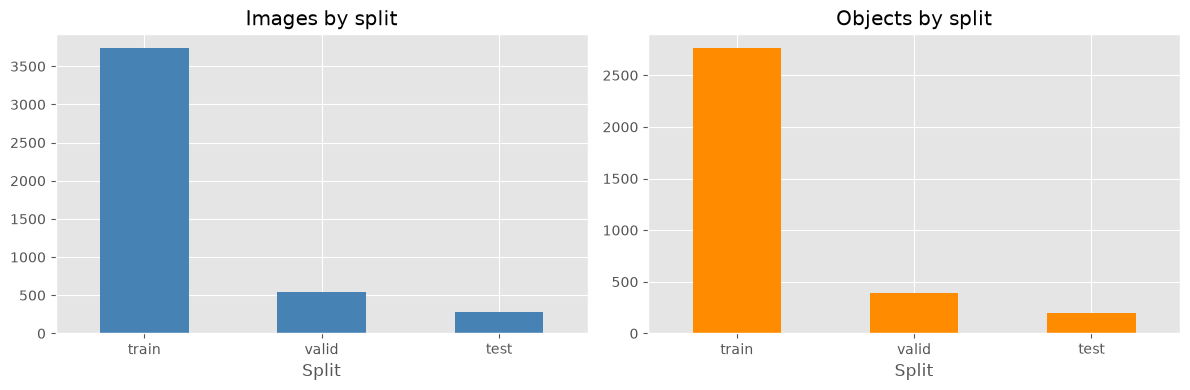

In [21]:
split_summary = (
    images_df.groupby("split", observed=True)
    .agg(
        images=("image_path", "count"),
        objects=("num_objects", "sum"),
        empty_images=("num_objects", lambda values: (values == 0).sum()),
        avg_objects_per_image=("num_objects", "mean"),
        min_width=("width", "min"),
        max_width=("width", "max"),
        min_height=("height", "min"),
        max_height=("height", "max"),
    )
    .reindex(["train", "valid", "test"])
)
display(split_summary.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
split_summary["images"].plot.bar(ax=axes[0], title="Images by split", color="steelblue")
split_summary["objects"].plot.bar(ax=axes[1], title="Objects by split", color="darkorange")
for axis in axes:
    axis.set_xlabel("Split")
    axis.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 4. 클래스 분포 및 불균형 확인

split,train,valid,test,total
class_name,,,,
cancel,938,125,69,1132
start,1020,126,59,1205
stop,808,144,69,1021
background (no objects),976,146,81,1203


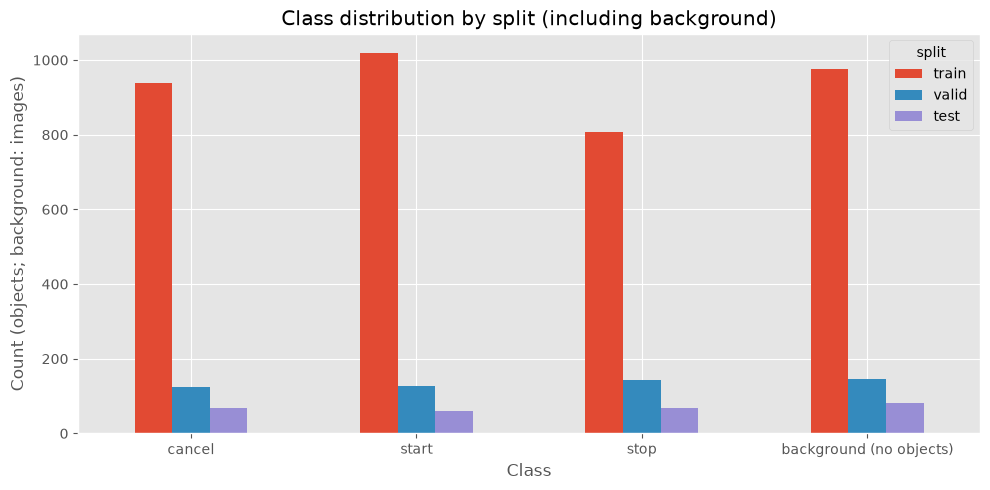

학습 데이터 최대/최소 클래스 비율: 1.26배


In [22]:
class_counts = pd.crosstab(objects_df["class_name"], objects_df["split"])
class_counts = class_counts.reindex(index=list(class_names.values()), fill_value=0)
class_counts = class_counts.reindex(columns=["train", "valid", "test"], fill_value=0)
class_counts["total"] = class_counts.sum(axis=1)
# Background is a display-only category: count images with zero valid objects.
background_counts = (
    images_df.loc[images_df["num_objects"].eq(0)]
    .groupby("split", observed=True).size()
    .reindex(["train", "valid", "test"], fill_value=0)
)
plot_counts = class_counts.copy()
plot_counts.loc["background (no objects)", ["train", "valid", "test"]] = background_counts
plot_counts["total"] = plot_counts[["train", "valid", "test"]].sum(axis=1)
plot_counts = plot_counts.astype(int)
display(plot_counts)

ax = plot_counts.drop(columns="total").plot.bar(figsize=(10, 5), title="Class distribution by split (including background)")
ax.set_xlabel("Class")
ax.set_ylabel("Count (objects; background: images)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

train_counts = class_counts["train"]
if len(train_counts) and train_counts.min() > 0:
    print(f"학습 데이터 최대/최소 클래스 비율: {train_counts.max() / train_counts.min():.2f}배")

&rightarrow; 데이터 라벨들의 균형이 잘 잡혀있는 편

## 5. 분할 간 동일 이미지 누출 검사

파일 내용의 MD5 해시를 비교하여 train/valid/test 사이의 완전 동일한 이미지를 찾습니다.

In [23]:
def file_md5(path):
    digest = md5()
    with Path(path).open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

hash_df = images_df[["split", "image_path"]].copy()
hash_df["md5"] = hash_df["image_path"].map(file_md5)
duplicate_hashes = hash_df.groupby("md5")["split"].nunique()
leaked_hashes = duplicate_hashes[duplicate_hashes > 1].index
leakage_df = hash_df[hash_df["md5"].isin(leaked_hashes)].sort_values(["md5", "split"])

print(f"서로 다른 split에 중복된 이미지 그룹: {len(leaked_hashes):,}개")
display(leakage_df.head(30) if not leakage_df.empty else pd.DataFrame({"결과": ["분할 간 동일 이미지가 없습니다."]}))

서로 다른 split에 중복된 이미지 그룹: 0개


,결과
0,분할 간 동일 이미지가 없습니다.


&rightarrow; train/validation/test에서 겹치는 사진 없음

## 6. 라벨이 표시된 샘플 이미지

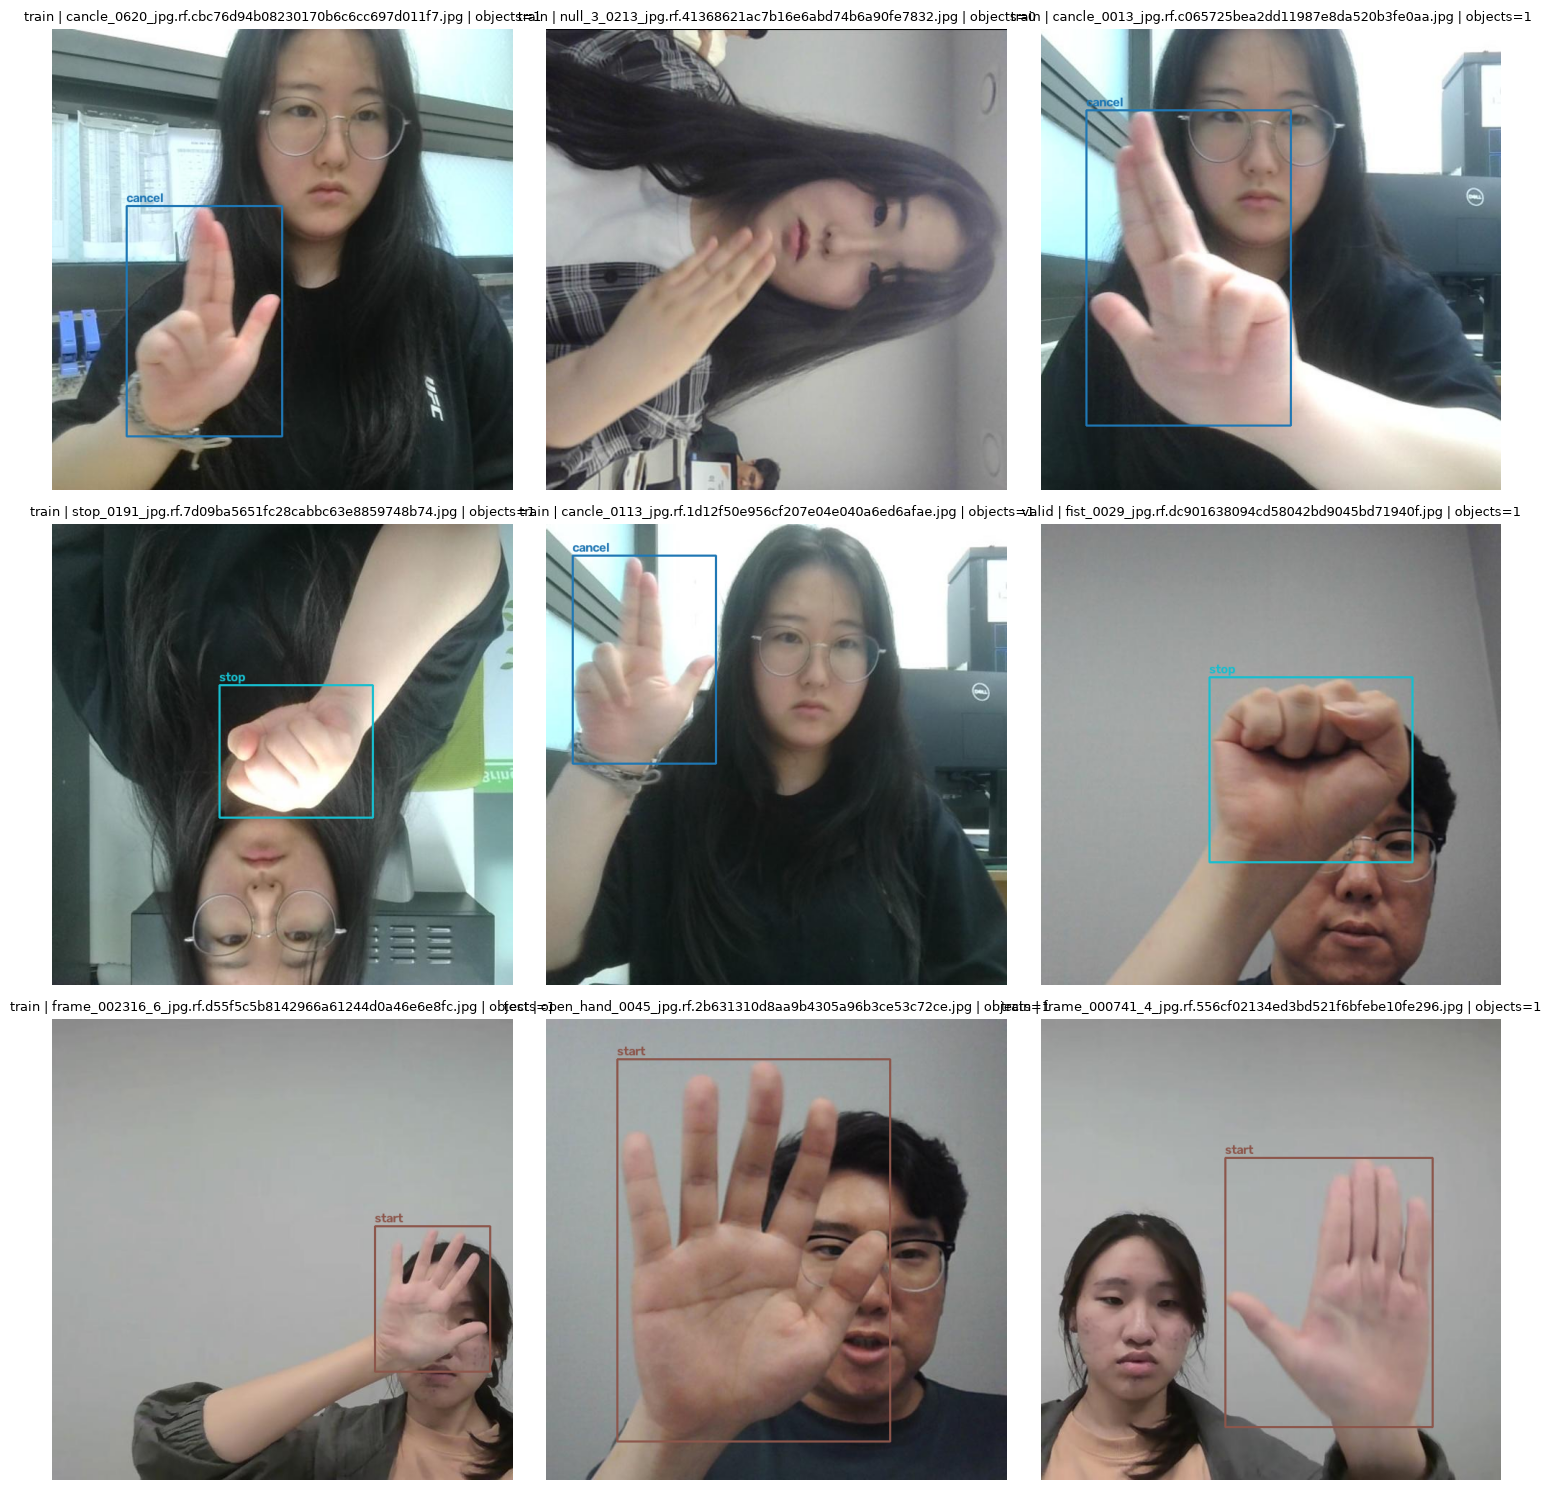

In [24]:
COLORS = plt.cm.tab10(np.linspace(0, 1, max(len(class_names), 1)))[:, :3] * 255

def draw_labels(image_path):
    row = images_df.loc[images_df["image_path"] == str(image_path)].iloc[0]
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    height, width = image.shape[:2]
    image_objects = objects_df[objects_df["image_path"] == str(image_path)]

    for obj in image_objects.itertuples():
        x1 = int((obj.x_center - obj.box_width_norm / 2) * width)
        y1 = int((obj.y_center - obj.box_height_norm / 2) * height)
        x2 = int((obj.x_center + obj.box_width_norm / 2) * width)
        y2 = int((obj.y_center + obj.box_height_norm / 2) * height)
        color = tuple(int(value) for value in COLORS[obj.class_id])
        cv2.rectangle(image, (x1, y1), (x2, y2), color, max(2, width // 400))
        cv2.putText(image, obj.class_name, (max(0, x1), max(15, y1 - 5)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
    return image, f"{row['split']} | {Path(image_path).name} | objects={row['num_objects']}"

sample_count = min(9, len(images_df))
sample_paths = images_df.sample(sample_count, random_state=RANDOM_SEED)["image_path"].tolist()
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
for axis in axes.flat:
    axis.axis("off")
for axis, image_path in zip(axes.flat, sample_paths):
    image, title = draw_labels(image_path)
    axis.imshow(image)
    axis.set_title(title, fontsize=9)
plt.tight_layout()
plt.show()

## 7. 최종 체크 요약

In [25]:
checks = {
    "총 이미지 수": len(images_df),
    "총 객체 수": len(objects_df),
    "라벨/이미지 문제 수": len(issues_df),
    "객체가 없는 이미지 수": int((images_df["num_objects"] == 0).sum()),
    "split 간 중복 이미지 그룹 수": len(leaked_hashes),
    "학습 데이터 미등장 클래스": ", ".join(train_counts[train_counts == 0].index) or "없음",
}
display(pd.DataFrame(checks.items(), columns=["항목", "값"]))

if len(issues_df) == 0 and len(leaked_hashes) == 0 and (train_counts > 0).all():
    print("기본 무결성 검사 결과, 학습을 시작할 수 있는 상태입니다.")
else:
    print("위에서 발견된 문제와 클래스 불균형을 확인한 후 학습을 진행하세요.")

,항목,값
0,총 이미지 수,4561
1,총 객체 수,3358
2,라벨/이미지 문제 수,1203
3,객체가 없는 이미지 수,1203
4,split 간 중복 이미지 그룹 수,0
5,학습 데이터 미등장 클래스,없음


위에서 발견된 문제와 클래스 불균형을 확인한 후 학습을 진행하세요.


## 8. 모델 평가

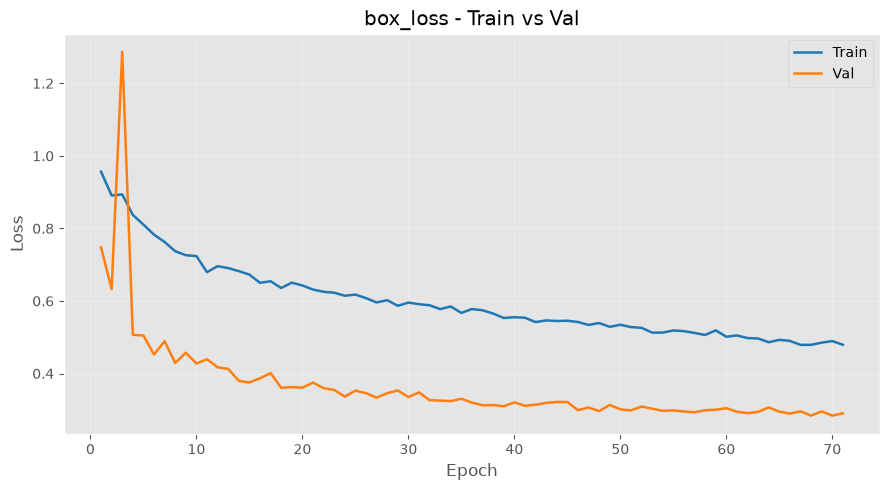

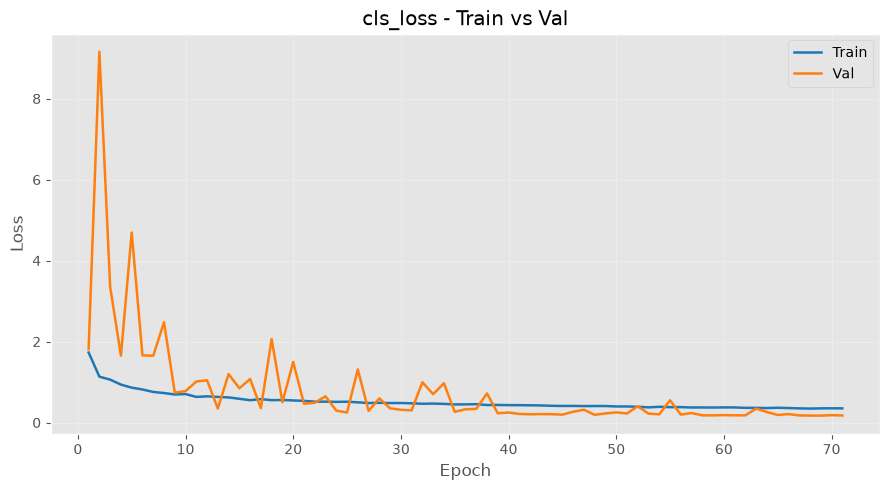

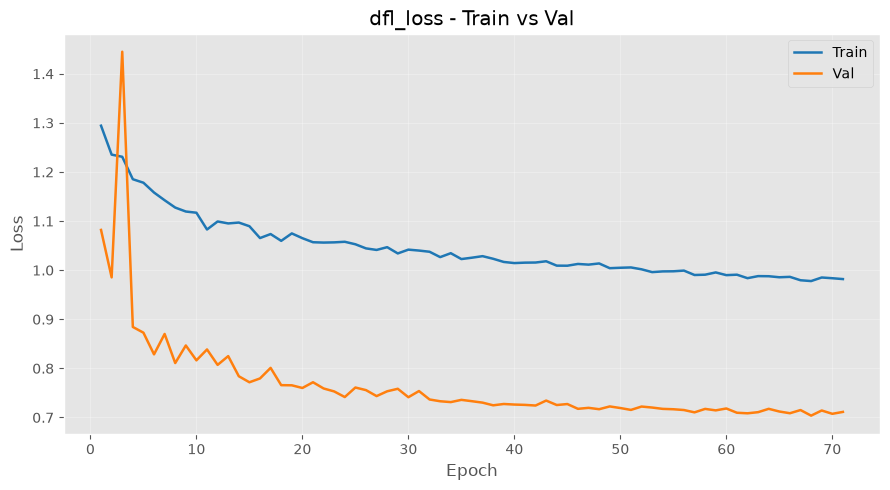

Loaded 71 epochs from runs\yolo\gesture_yolov8n-3\results.csv
Graphs saved to: C:\Users\Admin\motion_detect\runs\yolo\gesture_yolov8n-3\loss_plots


In [27]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Change this path to compare losses from another training run.
RESULTS_CSV = Path("runs/yolo/gesture_yolov8n-3/results.csv")
SAVE_PLOTS = True

if not RESULTS_CSV.is_file():
    raise FileNotFoundError(f"CSV not found: {RESULTS_CSV.resolve()}. Run from the project root.")

loss_history = pd.read_csv(RESULTS_CSV)
loss_history.columns = loss_history.columns.str.strip()
loss_types = ("box_loss", "cls_loss", "dfl_loss")
required_columns = ["epoch"] + [
    f"{split}/{loss_type}" for loss_type in loss_types for split in ("train", "val")
]
missing_columns = sorted(set(required_columns) - set(loss_history.columns))
if missing_columns:
    raise ValueError(f"Missing CSV columns: {missing_columns}")
loss_history[required_columns] = loss_history[required_columns].apply(pd.to_numeric, errors="raise")
loss_history = loss_history.sort_values("epoch")
if loss_history.empty:
    raise ValueError("No completed epochs in results.csv yet.")

plot_dir = RESULTS_CSV.parent / "loss_plots"
if SAVE_PLOTS:
    plot_dir.mkdir(parents=True, exist_ok=True)

# Each loss gets its own figure containing both train and validation curves.
for loss_type in loss_types:
    fig, ax = plt.subplots(figsize=(9, 5))
    for split, color in (("train", "tab:blue"), ("val", "tab:orange")):
        ax.plot(
            loss_history["epoch"], loss_history[f"{split}/{loss_type}"],
            label=split.capitalize(), color=color, linewidth=1.8,
        )
    ax.set(title=f"{loss_type} - Train vs Val", xlabel="Epoch", ylabel="Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    if SAVE_PLOTS:
        fig.savefig(plot_dir / f"{loss_type}.png", dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"Loaded {len(loss_history)} epochs from {RESULTS_CSV}")
if SAVE_PLOTS:
    print(f"Graphs saved to: {plot_dir.resolve()}")
